# Spheroid Segmentation with Boundary-Aware U-Net
## Training and Testing Pipeline

**Required files in same directory:**
- `boundary_losses.py`
- `boundary_metrics.py`

## Cell 1: Environment Setup
**Run this ONCE to create conda environment**

## Cell 2: Verify Environment

In [1]:
import torch
import fastai
import cv2
import numpy as np

print("="*70)
print("ENVIRONMENT VERIFICATION")
print("="*70)
print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
print(f"FastAI: {fastai.__version__}")
print(f"OpenCV: {cv2.__version__}")
print("="*70)

ENVIRONMENT VERIFICATION
PyTorch: 2.4.1
CUDA Available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM: 4.00 GB
FastAI: 2.7.17
OpenCV: 4.8.1


## Cell 3: Check Dataset

In [2]:
from pathlib import Path

PATH_TO_DATASET = Path('./data/organized')

print("="*70)
print("DATASET CHECK")
print("="*70)

for split in ['train', 'val', 'test']:
    img_dir = PATH_TO_DATASET / 'images' / split
    mask_dir = PATH_TO_DATASET / 'masks' / split
    if img_dir.exists() and mask_dir.exists():
        img_count = len(list(img_dir.glob('*.png')))
        mask_count = len(list(mask_dir.glob('*.png')))
        print(f"✅ {split:5s}: {img_count} images, {mask_count} masks")
    else:
        print(f"❌ {split:5s}: Missing directory")
print("="*70)

DATASET CHECK
✅ train: 335 images, 335 masks
✅ val  : 71 images, 71 masks
✅ test : 70 images, 70 masks


## Cell 4: Import Custom Modules

In [3]:
from boundary_losses import CombinedBoundaryLoss
from boundary_metrics import BoundaryIoU, BoundaryF1, AreaAccuracy, accuracy_spheroid, calculate_boundary_metrics

print("✅ Custom modules imported!")

✅ Custom modules imported!


## Cell 5: Import Libraries

In [4]:
import random
import time
import matplotlib.pyplot as plt
from torch import backends
from fastai.data.block import DataBlock
from fastai.data.transforms import FuncSplitter, Normalize, get_image_files
from fastai.metrics import Dice, JaccardCoeff
from fastai.callback.tracker import EarlyStoppingCallback, SaveModelCallback
from fastai.torch_core import set_seed
from fastai.vision.core import PILImage, PILMask
from fastai.vision.data import ImageBlock, MaskBlock, imagenet_stats
from fastai.vision.augment import Resize, aug_transforms, ResizeMethod
from fastai.optimizer import Adam
import segmentation_models_pytorch as smp
from fastai.vision.all import *

# Set seeds
SEED = 2021
set_seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
backends.cudnn.deterministic = True
backends.cudnn.benchmark = False

CODES = np.array(['Background', 'Spheroid'])
print("✅ Libraries imported!")

c:\Users\tulas\anaconda3\envs\spheroid_seg\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Libraries imported!


## Cell 6: Helper Functions

In [5]:
def get_mask(img_path):
    img_path = Path(img_path)
    # Change .jpg to .png for mask
    mask_name = img_path.stem + '.png'
    return PATH_TO_DATASET / 'masks' / img_path.parent.name / mask_name

def train_val_splitter(path):
    return 'val' not in Path(path).parts

def get_dataloader(img_size, bs=4, use_augmentation=True):
    batch_tfms = [Normalize.from_stats(*imagenet_stats)]
    if use_augmentation:
        batch_tfms = aug_transforms(size=img_size, min_scale=0.75) + batch_tfms
    
    # Custom function to get .jpg files
    def get_image_files_jpg(path):
        return get_image_files(path, folders=['train', 'val']).filter(lambda x: x.suffix in ['.jpg', '.jpeg', '.png'])
    
    spheroids = DataBlock(
        blocks=(ImageBlock, MaskBlock(CODES)),
        get_items=get_image_files_jpg,
        get_y=get_mask,
        splitter=FuncSplitter(train_val_splitter),
        item_tfms=Resize(img_size, ResizeMethod.Squish),
        batch_tfms=batch_tfms
    )
    
    dls = spheroids.dataloaders(PATH_TO_DATASET / 'images', bs=bs)
    print(f"✅ Train: {len(dls.train)} batches | Valid: {len(dls.valid)} batches")
    return dls

def pixel_accuracy(inp, targ):
    """Simple accuracy metric that works with FastAI"""
    targ = targ.squeeze(1)
    pred = inp.argmax(dim=1)
    return (pred == targ).float().mean()

def init_learner(dls, loss_func, opt_func=Adam):
    from fastai.vision.all import unet_learner
    
    # Use FastAI's native U-Net (compatible with training loop)
    learn = unet_learner(
        dls,
        resnet34,
        n_out=2,
        loss_func=loss_func,
        opt_func=opt_func,
        metrics=[Dice(), pixel_accuracy],
        pretrained=True
    )
    
    print(f"✅ Model initialized | Parameters: {sum(p.numel() for p in learn.model.parameters()):,}")
    return learn

print("✅ Helper functions defined!")

✅ Helper functions defined!


## Cell 7: Configuration

In [6]:
CONFIG = {
    'model_name': 'unet_resnet34_spheroid_boundary',
    'image_size': 512,
    'batch_size': 4,
    'epochs': 30,
    'learning_rate': 1e-4,
    'loss_function': CombinedBoundaryLoss(alpha_bce=1.0, alpha_iou=1.0, alpha_boundary=2.0, alpha_area=0.5),
    'optimizer': Adam,
    'use_augmentation': True,
}

print("="*70)
print("TRAINING CONFIGURATION")
print("="*70)
for k, v in CONFIG.items():
    if k != 'loss_function':
        print(f"  {k}: {v}")
    else:
        print(f"  {k}: CombinedBoundaryLoss")
print("="*70)

TRAINING CONFIGURATION
  model_name: unet_resnet34_spheroid_boundary
  image_size: 512
  batch_size: 4
  epochs: 30
  learning_rate: 0.0001
  loss_function: CombinedBoundaryLoss
  optimizer: <function Adam at 0x000001FE29CD5280>
  use_augmentation: True


## Cell 8: Create Dataloader & Model

✅ Train: 17 batches | Valid: 84 batches
✅ Saved: training_batch_sample.png


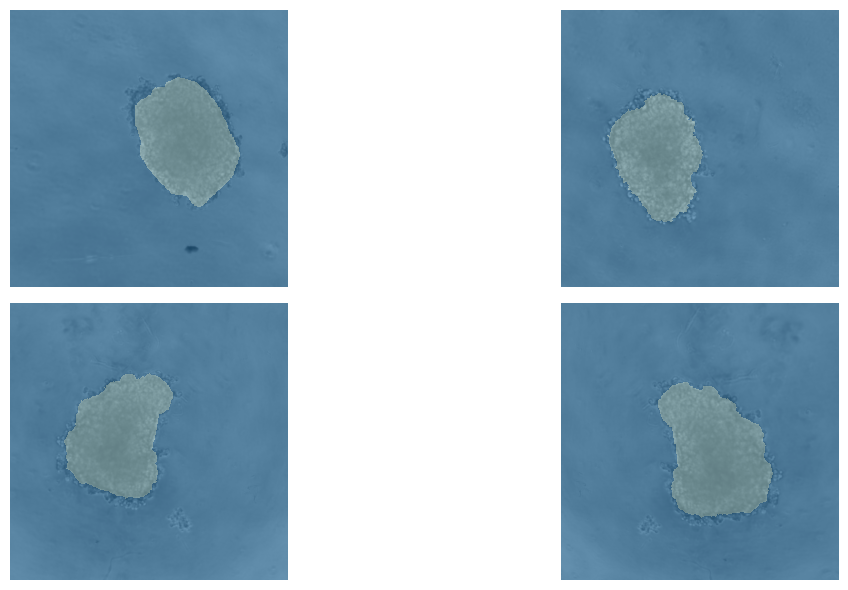

In [7]:
img_size = (CONFIG['image_size'], CONFIG['image_size'])
dls = get_dataloader(img_size, bs=CONFIG['batch_size'], use_augmentation=CONFIG['use_augmentation'])

# Show sample
dls.show_batch(vmin=0, vmax=1, figsize=(14, 6))
plt.tight_layout()
plt.savefig('training_batch_sample.png', dpi=150, bbox_inches='tight')
print("✅ Saved: training_batch_sample.png")

In [8]:
learn = init_learner(dls, loss_func=CONFIG['loss_function'], opt_func=CONFIG['optimizer'])

✅ Model initialized | Parameters: 41,221,168


## Cell 9: Find LR (Optional)

In [9]:
if CONFIG['learning_rate'] is None:
    sugg_lr = learn.lr_find()
    CONFIG['learning_rate'] = sugg_lr.valley
    print(f"Using LR: {CONFIG['learning_rate']}")
else:
    print(f"Using LR: {CONFIG['learning_rate']}")

Using LR: 0.0001


## Cell 10: TRAIN

In [10]:
print("\n" + "="*70)
print("🚀 TRAINING STARTED")
print("="*70)

# Train without callbacks first to test
learn.fit_one_cycle(CONFIG['epochs'], CONFIG['learning_rate'])

print("="*70)
print("✅ TRAINING COMPLETED")
print("="*70)

# Manually save
learn.save(CONFIG['model_name'])
print(f"📁 Model saved: models/{CONFIG['model_name']}.pth")


🚀 TRAINING STARTED


epoch,train_loss,valid_loss,dice,pixel_accuracy,time
0,3.651977,8231346.000000,0.012405,0.876332,10:47
1,2.802476,143297024.000000,0.715615,0.944561,10:26
2,2.487958,224898528.000000,0.908042,0.977061,10:24
3,2.189862,202847760.000000,0.918373,0.980302,10:24
4,1.995757,207434320.000000,0.922736,0.981081,10:26
5,1.853379,236319424.000000,0.921475,0.980317,10:24
6,1.780118,182650752.000000,0.897242,0.976784,10:22
7,1.690631,188680608.000000,0.913465,0.979936,10:23
8,1.613412,208798528.000000,0.926657,0.982381,10:22
9,1.552724,211041792.000000,0.927278,0.982567,10:21


✅ TRAINING COMPLETED
📁 Model saved: models/unet_resnet34_spheroid_boundary.pth


## Cell 11: Validation

In [11]:
learn.load(CONFIG['model_name'])
val_results = learn.validate()
metric_names = ['valid_loss'] + [item.name for item in learn.metrics.items]

print("\n" + "="*70)
print("VALIDATION RESULTS")
print("="*70)
for name, value in zip(metric_names, val_results):
    print(f"  {name:20s}: {value:.4f}")
print("="*70)

c:\Users\tulas\anaconda3\envs\spheroid_seg\lib\site-packages\fastai\learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device


VALIDATION RESULTS
  valid_loss          : 194265680.0000
  dice                : 0.9361
  pixel_accuracy      : 0.9848


## Cell 12: Test Inference

In [14]:
test_img_dir = PATH_TO_DATASET / 'images' / 'test'
test_mask_dir = PATH_TO_DATASET / 'masks' / 'test'
test_images = sorted(test_img_dir.glob('*.png'))

print(f"\n📂 Found {len(test_images)} test images")
print("🚀 Running inference...\n")

start_time = time.time()
all_metrics = {'dice': [], 'iou': [], 'accuracy': [], 'boundary_iou': [], 'area_accuracy': []}
predictions_data = []

learn.model.eval()
with torch.no_grad():
    for idx, img_path in enumerate(test_images):
        img_pil = PILImage.create(img_path)
        
        # Change .jpg to .png for mask
        mask_name = img_path.stem + '.png'
        mask_pil = PILMask.create(test_mask_dir / mask_name)
        
        pred_class, _, _ = learn.predict(img_pil)
        pred = np.array(pred_class)
        target = np.array(mask_pil)
        image = np.array(img_pil)
        
        if pred.shape != target.shape:
            pred = cv2.resize(pred.astype(np.uint8), (target.shape[1], target.shape[0]), interpolation=cv2.INTER_NEAREST)
        
        metrics = calculate_boundary_metrics(pred, target)
        for k in all_metrics:
            all_metrics[k].append(metrics[k])
        
        predictions_data.append({'image': image, 'pred': pred, 'target': target, 'metrics': metrics, 'filename': img_path.name})
        
        if (idx + 1) % 10 == 0:
            print(f"  Processed {idx + 1}/{len(test_images)}")




📂 Found 70 test images
🚀 Running inference...



c:\Users\tulas\Desktop\DrugEfficacy\Unet_latest2112\boundary_metrics.py:194: RuntimeWarning: overflow encountered in scalar subtract
  area_accuracy = 1.0 - abs(pred_area - target_area) / (target_area + 1e-8)


  Processed 10/70


  Processed 20/70


  Processed 30/70


  Processed 40/70


  Processed 50/70


  Processed 60/70


  Processed 70/70


## Cell 13: Test Results

In [15]:
test_results = {f'{k}_{stat}': func(all_metrics[k]) 
                for k in all_metrics 
                for stat, func in [('mean', np.mean), ('std', np.std), ('min', np.min), ('max', np.max)]}

print("\n" + "="*70)
print("TEST RESULTS")
print("="*70)
for metric in ['dice', 'iou', 'boundary_iou', 'area_accuracy', 'accuracy']:
    print(f"\n{metric.upper()}:")
    print(f"  Mean: {test_results[f'{metric}_mean']:.4f} ± {test_results[f'{metric}_std']:.4f}")
    print(f"  Range: [{test_results[f'{metric}_min']:.4f}, {test_results[f'{metric}_max']:.4f}]")
print("="*70)


TEST RESULTS

DICE:
  Mean: 0.9473 ± 0.0227
  Range: [0.8639, 0.9783]

IOU:
  Mean: 0.9007 ± 0.0397
  Range: [0.7604, 0.9575]

BOUNDARY_IOU:
  Mean: 0.0907 ± 0.0448
  Range: [0.0087, 0.2199]

AREA_ACCURACY:
  Mean: -6550.8405 ± 4114.0619
  Range: [-12073.3353, 0.9949]

ACCURACY:
  Mean: 0.9865 ± 0.0082
  Range: [0.9610, 0.9962]


## Cell 14: Save Visualizations

In [17]:
output_dir = Path('test_predictions')
output_dir.mkdir(exist_ok=True)

for idx, data in enumerate(predictions_data):
    image, pred, target, metrics = data['image'], data['pred'], data['target'], data['metrics']
    
    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    if image.shape[:2] != target.shape:
        image = cv2.resize(image, (target.shape[1], target.shape[0]))
    
    h, w = target.shape
    img_original = image.copy()
    
    # GT overlay
    img_gt = image.copy()
    gt_overlay = np.zeros_like(img_gt)
    gt_overlay[:, :, 1] = target * 255
    img_gt = cv2.addWeighted(img_gt, 0.7, gt_overlay, 0.3, 0)
    cv2.putText(img_gt, "Ground Truth (Green)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    
    # Pred overlay
    img_pred = image.copy()
    pred_overlay = np.zeros_like(img_pred)
    pred_overlay[:, :, 0] = pred * 255
    img_pred = cv2.addWeighted(img_pred, 0.7, pred_overlay, 0.3, 0)
    cv2.putText(img_pred, "Prediction (Blue)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
    
    # Contours
    img_contours = image.copy()
    target_contours, _ = cv2.findContours(target.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    pred_contours, _ = cv2.findContours(pred.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(img_contours, target_contours, -1, (0, 255, 0), 2)
    cv2.drawContours(img_contours, pred_contours, -1, (255, 0, 0), 2)
    
    cv2.putText(img_contours, f"Dice:{metrics['dice']:.3f} IoU:{metrics['iou']:.3f}", 
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    cv2.putText(img_contours, f"BIoU:{metrics['boundary_iou']:.3f} Area:{metrics['area_accuracy']:.3f}", 
                (10, 55), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    cv2.putText(img_contours, "GT: Green | Pred: Blue", (10, h - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    
    grid = np.vstack([np.hstack([img_original, img_contours]), np.hstack([img_gt, img_pred])])
    cv2.imwrite(str(output_dir / f'test_{idx:03d}.png'), grid)

print(f"✅ Saved {len(predictions_data)} visualizations to '{output_dir}/'")

✅ Saved 70 visualizations to 'test_predictions/'
